## Settings

In [31]:
## auto reload modules
%reload_ext autoreload
%autoreload 2

## Dependencies

In [32]:
## libraries
import sys
from pathlib import Path

## path
root = Path.cwd().resolve().parent
sys.path.insert(0, str(root))

## modules
from src.data.builders import load_processed_data
from src.estimators.factories import load_estimators
from src.evaluators.resampling import logo_cross_valid
from src.evaluators.structuring import (
    compile_structural_agreement,
    results_structural_agreement,
)

## constants
from src.evaluators.config import (
    FEAT_X,
    FEAT_Z,
    TARGET,
)

## Initialization

In [33]:
## reproducibility
N_DECIMALS = 2
N_REPEATS = 30
RANDOM_STATE = 42

## load data and models
data = load_processed_data()
models = load_estimators(random_state = RANDOM_STATE)

## view data shape
n_obs, n_feat = data.shape
print(f"Original Data: {n_feat} features, {n_obs} observations")

## view model surface
n_mods = len(models)
print(f"Learned Models: {n_mods} estimators")

Original Data: 32 features, 25 observations
Learned Models: 9 estimators


## Training

In [34]:
## leave-one-group-out cross validation (domain)
if "results_dict_domain" not in globals():
    results_dict_domain = dict()
    for name, model in models.items():
        print(f"Training {name}...")
        _, y_pred = logo_cross_valid(
            data = data,
            feat_x = FEAT_X,
            feat_z = FEAT_Z,
            estimator_c = model.estimator_c,
            estimator_r = model.estimator_r,
            target = TARGET,
            group = "domain",
            n_repeats = N_REPEATS,
            random_state = RANDOM_STATE
        )
        results_dict_domain[name] = y_pred

## Post-Processing

In [35]:
## consensus metrics per (model, held-out domain)
results_data_domain = compile_structural_agreement(
    predictions = results_dict_domain,
    data = data,
    target = TARGET,
    group = "domain"
)

## Structural Agreement Test
Leave-one-group-out (LOGO) cross-validation by domain evaluates whether held-out predictions agree with the structural ordering and dependence of observed capacities. Because frontier estimation is scale-arbitrary across fitting methods, the test uses structural agreement rather than residual norms.

- **Spearman (`ρ`)**: Global rank agreement between predicted and observed capacities.
- **Rank-Biased Overlap (`RBO`)**: Top-weighted agreement, emphasizing the high-capacity tail.
- **Distance Correlation (`DCR`)**: Nonlinear dependence between predictions and observations.
- **Composite Index (`CI`)**: Geometric mean of agreement-scaled `ρ`, `RBO`, and `DCR`.

### Reporting Convention
Each held-out domain contributes one value per estimator. The summary table reports held-out domains row-wise. `CI` is shown as median `[Q1–Q3]` across estimators; component columns report medians. Prior to compounding, `ρ` is rescaled from `[-1, 1]` to `[0, 1]` so that negative rank disagreement lowers `CI` without collapsing to a single floor. Aggregations are equally weighted across estimators. Higher values indicate stronger agreement.

In [36]:
## structural agreement results by held-out domain
results_domain = results_structural_agreement(
    results = results_data_domain,
    group_col = "group",
    index_name = "Domain",
    n_repeats = N_REPEATS,
    random_state = RANDOM_STATE,
    decimals = N_DECIMALS
)

display(results_domain)

Cross-Validation: 9 models, 30 repeats (seeds 42-71)
Across-model aggregation: median across learners within held-out domains
Resampling: LOGO domain splits are fixed across repeats
Weighting: domains and models are equally weighted; results are not observation-weighted


,CI [IQR],ρ,RBO,DCR
Domain,,,,
Earth & Physical Sciences,"0.88 [0.81, 0.91]",0.70,0.90,0.84
Life Sciences & Medicine,"0.92 [0.65, 0.94]",0.80,0.88,0.83
Technology & Information,"0.87 [0.82, 0.94]",0.80,0.93,0.89
Trade & Institutions,"0.96 [0.81, 0.97]",0.90,0.98,0.94
Transportation & Infrastructure,"0.83 [0.68, 0.95]",0.60,0.85,0.83


_Structural agreement is consistent across held-out domains. Median `CI` ranges from 0.83 to 0.96, with positive rank agreement (median `ρ` between 0.60 and 0.90) and elevated top-end agreement (`RBO`) across all domains. Agreement strength varies by domain but remains positive throughout, indicating that fitted frontiers preserve the observed capacity structure on unseen domains._

## Visualization

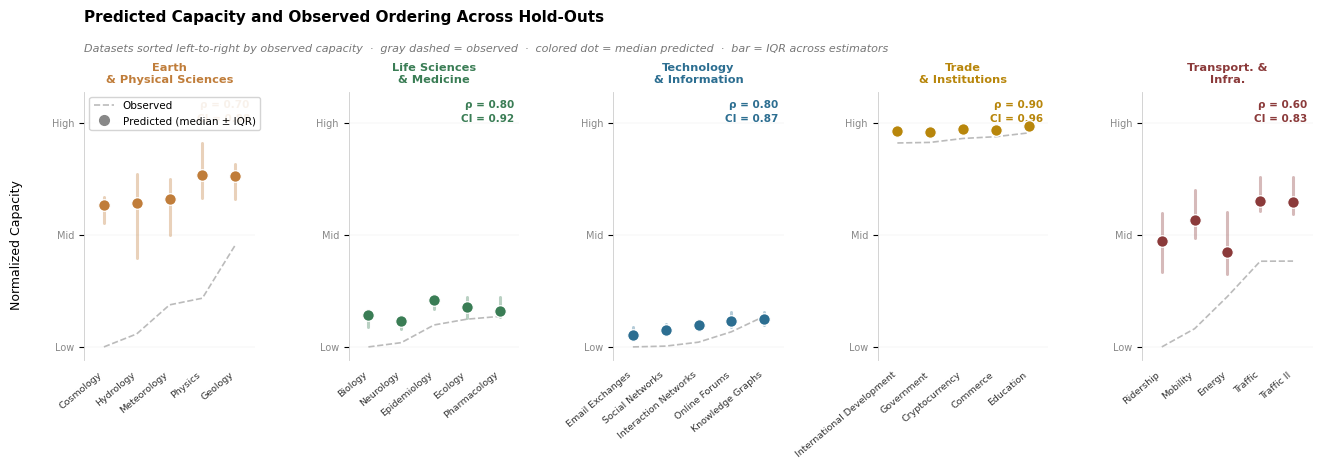

In [37]:

## libraries
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.transforms import blended_transform_factory
from src.vectorizers.scalers import _log_transformer

## ── palette ──────────────────────────────────────────────────────────────────
DOMAIN_PALETTE = {
    "Earth & Physical Sciences":      "#C07D3A",
    "Life Sciences & Medicine":       "#3A7D55",
    "Technology & Information":       "#2C6E91",
    "Trade & Institutions":           "#B8860B",
    "Transportation & Infrastructure":"#8B3A3A",
}
domain_order = list(DOMAIN_PALETTE.keys())

## ── ground truth ─────────────────────────────────────────────────────────────
y_true_log  = _log_transformer(data[TARGET]).astype(float).to_numpy()
domains_arr = data["domain"].to_numpy()
disc_arr    = data["discipline"].to_numpy()
model_names = list(results_dict_domain.keys())

## ── figure: 1 × 5 panels ─────────────────────────────────────────────────────
fig, axes = plt.subplots(
    1, len(domain_order),
    figsize = (13.5, 4.8),
    gridspec_kw = dict(wspace = 0.55),
)
fig.subplots_adjust(top = 0.80, bottom = 0.24, left = 0.06, right = 0.97)

fig.text(
    0.06, 0.97,
    "Predicted Capacity and Observed Ordering Across Hold-Outs",
    ha = "left", va = "top", fontsize = 11, fontweight = "semibold",
)
fig.text(
    0.06, 0.90,
    "Datasets sorted left-to-right by observed capacity  ·  "
    "gray dashed = observed  ·  colored dot = median predicted  ·  bar = IQR across estimators",
    ha = "left", va = "top", fontsize = 8, color = "#777", fontstyle = "italic",
)

for ax, domain in zip(axes, domain_order):
    mask  = domains_arr == domain
    n     = int(np.sum(mask))
    color = DOMAIN_PALETTE[domain]

    if n < 2:
        ax.set_visible(False)
        continue

    yt    = y_true_log[mask]
    discs = disc_arr[mask]

    ## sort by observed capacity (ascending)
    sort_idx    = np.argsort(yt)
    yt_sorted   = yt[sort_idx]
    disc_sorted = discs[sort_idx]
    x           = np.arange(n)

    ## per-estimator predictions, same sort order
    pred_mat = np.stack(
        [np.asarray(results_dict_domain[m], dtype = float)[mask][sort_idx]
         for m in model_names],
        axis = 0,
    )  ## (n_models, n)

    pred_med = np.median(pred_mat, axis = 0)
    pred_q1  = np.percentile(pred_mat, 25, axis = 0)
    pred_q3  = np.percentile(pred_mat, 75, axis = 0)

    ## scale observed and predictions together
    _lo = min(yt_sorted.min(), pred_mat.min())
    _hi = max(yt_sorted.max(), pred_mat.max())
    def _scale(v): return (v - _lo) / (_hi - _lo) if _hi > _lo else np.zeros_like(v)

    obs_s = _scale(yt_sorted)
    med_s = _scale(pred_med)
    q1_s  = _scale(pred_q1)
    q3_s  = _scale(pred_q3)

    ## ── observed reference ───────────────────────────────────────────────────
    ax.plot(x, obs_s,
            color = "#BBBBBB", lw = 1.2, ls = "--", zorder = 1)

    ## ── IQR bars + median dots ────────────────────────────────────────────────
    for i in range(n):
        ax.plot(
            [i, i], [q1_s[i], q3_s[i]],
            color = color, lw = 2.2, alpha = 0.35,
            solid_capstyle = "round", zorder = 3,
        )
        ax.scatter(
            i, med_s[i],
            color = color, s = 70, zorder = 5,
            edgecolors = "white", linewidths = 0.9,
        )

    ## ── ρ and CI annotation ──────────────────────────────────────────────────
    sub    = results_data_domain[results_data_domain["group"] == domain]
    rho_md = sub["rho"].median()
    ci_md  = sub["ci"].median()
    ax.text(
        0.97, 0.97,
        f"\u03c1 = {rho_md:.2f}\nCI = {ci_md:.2f}",
        transform = ax.transAxes,
        ha = "right", va = "top",
        fontsize = 7.5, color = color, fontweight = "semibold",
        linespacing = 1.5,
    )

    ## ── panel title ──────────────────────────────────────────────────────────
    short = (domain
             .replace("Transportation & Infrastructure", "Transport. &\nInfra.")
             .replace(" & ", "\n& "))
    ax.set_title(short, fontsize = 8.2, color = color, fontweight = "semibold",
                 pad = 6, linespacing = 1.3)

    ## ── x-axis dataset labels ────────────────────────────────────────────────
    ax.set_xticks(x)
    ax.set_xticklabels(
        disc_sorted,
        fontsize = 6.8, rotation = 40, ha = "right", color = "#333",
    )

    ## ── axes dressing ────────────────────────────────────────────────────────
    ax.set_xlim(-0.6, n - 0.4)
    ax.set_ylim(-0.06, 1.14)
    ax.set_yticks([0.0, 0.5, 1.0])
    ax.set_yticklabels(["Low", "Mid", "High"], fontsize = 7, color = "#888")
    ax.spines[["top", "right", "bottom"]].set_visible(False)
    ax.spines["left"].set_linewidth(0.6)
    ax.spines["left"].set_color("#CCCCCC")
    ax.yaxis.grid(True, lw = 0.35, color = "#EBEBEB", zorder = 0)
    ax.tick_params(axis = "x", bottom = False)
    ax.set_axisbelow(True)

## ── shared y-label ───────────────────────────────────────────────────────────
fig.text(0.005, 0.48, "Normalized Capacity",
         ha = "left", va = "center", fontsize = 9, rotation = 90)

## ── legend ───────────────────────────────────────────────────────────────────
obs_handle  = mlines.Line2D([], [], color = "#BBBBBB", lw = 1.2,
                             ls = "--", label = "Observed")
pred_handle = mlines.Line2D([], [], marker = "o", lw = 0,
                             color = "#888888", markersize = 7,
                             label = "Predicted (median ± IQR)")
axes[0].legend(
    handles = [obs_handle, pred_handle],
    fontsize = 7.5, loc = "upper left",
    framealpha = 0.9, edgecolor = "#D0D0D0",
)

plt.show()
